In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import dct
from sklearn.linear_model import LinearRegression

# --- 1. Simulation Parameters ---
n = 500
T = 1.0  
# Use the "half-step" grid so DCT perfectly isolates frequencies without leakage
t = (np.arange(n) + 0.5) * T / n 

beta_true = 3.0 # The true causal effect we want to find
k1, k2 = 2, 5   # The confounded frequencies (Set G)

# --- 2. Generate Data ---
# Confounder (Sparse in DCT domain)
U_time = 2.0 * np.cos(np.pi * k1 * t / T) + 1.0 * np.cos(np.pi * k2 * t / T)

# Predictor X (White noise, but correlated with U to create confounding!)
X_noise = np.random.normal(0, 1, n)
X_time = X_noise + 0.8 * U_time 

# Noise eta
eta_time = np.random.normal(0, 0.5, n)

# Response Y (The DGP: Y = X*beta + U + eta)
Y_time = X_time * beta_true + U_time + eta_time

# --- 3. Transform to Frequency Domain ---
# norm='ortho' perfectly matches the paper's T_k operator
X_freq = dct(X_time, type=2, norm='ortho')
Y_freq = dct(Y_time, type=2, norm='ortho')
U_freq = dct(U_time, type=2, norm='ortho')

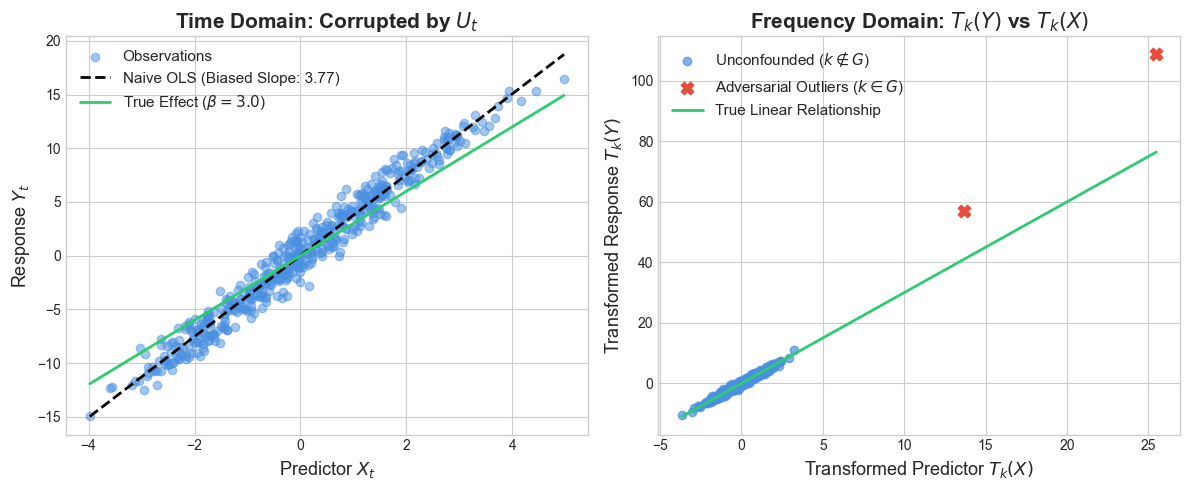

In [2]:
# --- 4. Visualization ---
plt.style.use('seaborn-v0_8-whitegrid') 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Time Domain (Standard OLS fails)
ax1.scatter(X_time, Y_time, alpha=0.5, color='#4A90E2', label='Observations')
# Fit standard OLS to time domain to show it is biased
ols_time = LinearRegression().fit(X_time.reshape(-1, 1), Y_time)
x_plot = np.linspace(X_time.min(), X_time.max(), 100)
ax1.plot(x_plot, ols_time.predict(x_plot.reshape(-1, 1)), color='black', linestyle='--', linewidth=2, label=f'Naive OLS (Biased Slope: {ols_time.coef_[0]:.2f})')
ax1.plot(x_plot, x_plot * beta_true, color='#2ECC71', linewidth=2, label=f'True Effect ($\\beta={beta_true}$)')

ax1.set_title('Time Domain: Corrupted by $U_t$', fontsize=15, fontweight='bold')
ax1.set_xlabel('Predictor $X_t$', fontsize=13)
ax1.set_ylabel('Response $Y_t$', fontsize=13)
ax1.legend(fontsize=11)

# Plot 2: Frequency Domain (The Deconfounded View)
# Identify outliers (where U_freq magnitude is effectively non-zero)
threshold = 1e-5
outlier_mask = np.abs(U_freq) > threshold
inlier_mask = ~outlier_mask

ax2.scatter(X_freq[inlier_mask], Y_freq[inlier_mask], alpha=0.7, color='#4A90E2', label='Unconfounded ($k \\notin G$)')
ax2.scatter(X_freq[outlier_mask], Y_freq[outlier_mask], color='#E74C3C', s=80, marker='X', label='Adversarial Outliers ($k \\in G$)')

x_plot_freq = np.linspace(X_freq.min(), X_freq.max(), 100)
ax2.plot(x_plot_freq, x_plot_freq * beta_true, color='#2ECC71', linewidth=2, label=f'True Linear Relationship')

ax2.set_title('Frequency Domain: $T_k(Y)$ vs $T_k(X)$', fontsize=15, fontweight='bold')
ax2.set_xlabel('Transformed Predictor $T_k(X)$', fontsize=13)
ax2.set_ylabel('Transformed Response $T_k(Y)$', fontsize=13)
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig('outlier_problem_visualization.pdf', format='pdf', bbox_inches='tight')
plt.show()